<a href="https://colab.research.google.com/github/Juli-Kareva/Fraud-detection-MDS/blob/main/Baseline_logreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline — Logistic Regression

## 1. Установка зависимостей и импорты

In [1]:
%pip install opendatasets

import opendatasets as od

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,   # == PR-AUC
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

RANDOM_STATE = 1208

## 2. Загрузка данных

In [3]:
BASE_DIR   = '/content'
TRAIN_PATH = os.path.join(BASE_DIR, 'df_train.csv')
TEST_PATH  = os.path.join(BASE_DIR, 'df_test.csv')
OOT_PATH   = os.path.join(BASE_DIR, 'df_oot.csv')

print(f'BASE_DIR  = {BASE_DIR}')

BASE_DIR  = /content


In [4]:
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df_oot   = pd.read_csv(OOT_PATH)

for name, df in [('Train', df_train), ('Test', df_test), ('OOT', df_oot)]:
    fraud_rate = df['fraud_bool'].mean() * 100
    print(f'{name:6s}: {len(df):>8,} строк | фрод {fraud_rate:.2f}%')

Train :  675,666 строк | фрод 1.00%
Test  :  119,323 строк | фрод 1.18%
OOT   :  205,011 строк | фрод 1.40%


In [5]:
VARIANT_NAMES = ['Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']

variants = {}
for vname in VARIANT_NAMES:
    fpath = os.path.join(BASE_DIR, f'{vname}.csv')
    if os.path.exists(fpath):
        v = pd.read_csv(fpath)
        variants[vname] = v
        fraud_rate = v['fraud_bool'].mean() * 100
        print(f'{vname:12s}: {len(v):>8,} строк | фрод {fraud_rate:.2f}%')
    else:
        print(f'Не найден: {fpath}')

print(f'\nЗагружено вариантов: {len(variants)}')

Variant I   : 1,000,000 строк | фрод 1.10%
Variant II  : 1,000,000 строк | фрод 1.10%
Variant III : 1,000,000 строк | фрод 1.10%
Variant IV  : 1,000,000 строк | фрод 1.10%
Variant V   : 1,000,000 строк | фрод 1.10%

Загружено вариантов: 5


## 3. Признаки и масштабирование

In [6]:
TARGET = 'fraud_bool'

FEATURES = [
    'name_email_similarity', 'session_length_in_minutes',
    'zip_count_4w', 'velocity_6h', 'credit_risk_score',
    'zip_count_4w_clean', 'current_address_months_count_clean',
    'date_of_birth_distinct_emails_4w', 'bank_branch_count_8w_clean',
    'bank_months_count', 'income', 'proposed_credit_limit',
    'customer_age', 'device_os_windows', 'email_is_free',
    'phone_home_valid', 'keep_alive_session', 'phone_mobile_valid',
    'housing_status_BC', 'payment_type_AB', 'payment_type_AC',
    'housing_status_BB', 'foreign_request', 'payment_type_AD',
    'has_other_cards', 'prev_address_months_count_clean',
    'employment_status_CB', 'employment_status_CC',
    'device_os_other', 'device_os_macintosh',
    'housing_status_BE', 'housing_status_BD',
    'source_TELEAPP', 'employment_status_CD', 'device_os_x11'
]

# Проверка наличия признаков
missing = [f for f in FEATURES if f not in df_train.columns]
if missing:
    print(f'⚠ Отсутствуют в train: {missing}')
else:
    print(f'Все {len(FEATURES)} признаков найдены ✓')

Все 35 признаков найдены ✓


In [9]:
# Смотрим сколько NaN в каждом сплите ДО скейлинга
for name, df in [('train', df_train), ('test', df_test), ('oot', df_oot)]:
    nan_cols = df[FEATURES].isnull().sum()
    nan_cols = nan_cols[nan_cols > 0]
    if len(nan_cols) > 0:
        print(f"\n {name.upper()} — NaN найдены:")
        print(nan_cols.to_string())
    else:
        print(f"✓ {name}: NaN нет")


⚠ TRAIN — NaN найдены:
velocity_6h                                9
current_address_months_count_clean      2827
prev_address_months_count_clean       469907
✓ test: NaN нет
✓ oot: NaN нет


In [10]:
from sklearn.impute import SimpleImputer
import numpy as np

FILL_MINUS1  = ['prev_address_months_count_clean']
FILL_MEDIAN  = ['current_address_months_count_clean', 'velocity_6h']

def apply_imputation(df, median_fills, fit=False):
    global _median_store
    arr = df[FEATURES].copy()

    for col in FILL_MINUS1:
        arr[col] = arr[col].fillna(-1)

    if fit:
        _median_store = {col: df[col].median() for col in median_fills}
    for col in median_fills:
        arr[col] = arr[col].fillna(_median_store[col])

    return arr.values

_median_store = {}

X_train_imp = apply_imputation(df_train, FILL_MEDIAN, fit=True)
X_test_imp  = apply_imputation(df_test,  FILL_MEDIAN, fit=False)
X_oot_imp   = apply_imputation(df_oot,   FILL_MEDIAN, fit=False)

print(f"Медианы (из train): { {k: round(v,2) for k,v in _median_store.items()} }")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)
X_oot   = scaler.transform(X_oot_imp)

# Variants
variants_scaled = {}
for vname, vdf in variants.items():
    missing_v = [f for f in FEATURES if f not in vdf.columns]
    if missing_v:
        print(f"⚠ {vname}: отсутствуют {missing_v}")
        continue
    X_v = apply_imputation(vdf, FILL_MEDIAN, fit=False)
    variants_scaled[vname] = {
        'X': scaler.transform(X_v),
        'y': vdf[TARGET].values
    }

for name, arr in [('train', X_train), ('test', X_test), ('oot', X_oot)]:
    n_nan = np.isnan(arr).sum()
    status = '✓' if n_nan == 0 else f'⚠ {n_nan} NaN!'
    print(f"{status} {name}: shape {arr.shape}")

joblib.dump(scaler,        'scaler_baseline.pkl')
joblib.dump(_median_store, 'median_store.pkl')
print('\nСкейлер и медианы сохранены ✓')

Медианы (из train): {'current_address_months_count_clean': 48.0, 'velocity_6h': 6274.67}
✓ train: shape (675666, 35)
✓ test: shape (119323, 35)
✓ oot: shape (205011, 35)

Скейлер и медианы сохранены ✓


## 4. Обучение Logistic Regression

In [11]:
logreg = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    C=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Обучаем LogReg... (может занять 1-2 минуты на 675k строк)')
logreg.fit(X_train, y_train)
print('Модель обучена ✓')

Обучаем LogReg... (может занять 1-2 минуты на 675k строк)
Модель обучена ✓


## 5. Функция оценки

In [12]:
def evaluate(model, X, y, split_name: str, threshold: float = 0.5) -> dict:

    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)

    roc_auc  = roc_auc_score(y, proba)
    pr_auc   = average_precision_score(y, proba)
    f1       = f1_score(y, pred, pos_label=1, zero_division=0)
    prec     = precision_score(y, pred, pos_label=1, zero_division=0)
    rec      = recall_score(y, pred, pos_label=1, zero_division=0)
    fraud_rt = y.mean() * 100

    return {
        'Split':       split_name,
        'Fraud%':      round(fraud_rt, 2),
        'ROC-AUC':     round(roc_auc, 4),
        'PR-AUC':      round(pr_auc,  4),
        'F1':          round(f1,      4),
        'Precision':   round(prec,    4),
        'Recall':      round(rec,     4),
    }

print('Функция evaluate() определена ✓')

Функция evaluate() определена ✓


## 6. Прогон по всем срезам

In [13]:
results = []

for split_name, X, y in [
    ('Train',  X_train, y_train),
    ('Test',   X_test,  y_test),
    ('OOT (month>5)', X_oot, y_oot),
]:
    res = evaluate(logreg, X, y, split_name)
    results.append(res)
    print(f"{res['Split']:22s} | ROC-AUC {res['ROC-AUC']:.4f} | PR-AUC {res['PR-AUC']:.4f} | F1 {res['F1']:.4f}")

# Variants
print()
for vname, vdata in variants_scaled.items():
    res = evaluate(logreg, vdata['X'], vdata['y'], vname)
    results.append(res)
    print(f"{res['Split']:22s} | ROC-AUC {res['ROC-AUC']:.4f} | PR-AUC {res['PR-AUC']:.4f} | F1 {res['F1']:.4f}")

Train                  | ROC-AUC 0.8495 | PR-AUC 0.0770 | F1 0.0515
Test                   | ROC-AUC 0.8462 | PR-AUC 0.0872 | F1 0.0660
OOT (month>5)          | ROC-AUC 0.8499 | PR-AUC 0.0997 | F1 0.0774

Variant I              | ROC-AUC 0.8240 | PR-AUC 0.0644 | F1 0.0581
Variant II             | ROC-AUC 0.8539 | PR-AUC 0.0820 | F1 0.0488
Variant III            | ROC-AUC 0.8201 | PR-AUC 0.0614 | F1 0.0468
Variant IV             | ROC-AUC 0.8503 | PR-AUC 0.0797 | F1 0.0490
Variant V              | ROC-AUC 0.8238 | PR-AUC 0.0653 | F1 0.0470


## 7. Итоговая таблица и визуализация деградации

In [14]:
df_results = pd.DataFrame(results)

def color_delta(val, ref, fmt='.4f'):
    delta = val - ref
    sign = '+' if delta >= 0 else ''
    return f'{val:{fmt}} ({sign}{delta:.4f})'

test_roc = df_results.loc[df_results['Split']=='Test', 'ROC-AUC'].values[0]
test_pr  = df_results.loc[df_results['Split']=='Test', 'PR-AUC'].values[0]
test_f1  = df_results.loc[df_results['Split']=='Test', 'F1'].values[0]

df_display = df_results.copy()
df_display['ΔROC vs Test'] = df_display['ROC-AUC'].apply(
    lambda x: f"{x-test_roc:+.4f}")
df_display['ΔPR vs Test']  = df_display['PR-AUC'].apply(
    lambda x: f"{x-test_pr:+.4f}")
df_display['ΔF1 vs Test']  = df_display['F1'].apply(
    lambda x: f"{x-test_f1:+.4f}")

display(df_display[['Split','Fraud%','ROC-AUC','PR-AUC','F1',
                     'ΔROC vs Test','ΔPR vs Test','ΔF1 vs Test']])

,Split,Fraud%,ROC-AUC,PR-AUC,F1,ΔROC vs Test,ΔPR vs Test,ΔF1 vs Test
0,Train,1.00,0.8495,0.0770,0.0515,+0.0033,-0.0102,-0.0145
1,Test,1.18,0.8462,0.0872,0.0660,+0.0000,+0.0000,+0.0000
2,OOT (month>5),1.40,0.8499,0.0997,0.0774,+0.0037,+0.0125,+0.0114
3,Variant I,1.10,0.8240,0.0644,0.0581,-0.0222,-0.0228,-0.0079
4,Variant II,1.10,0.8539,0.0820,0.0488,+0.0077,-0.0052,-0.0172
5,Variant III,1.10,0.8201,0.0614,0.0468,-0.0261,-0.0258,-0.0192
6,Variant IV,1.10,0.8503,0.0797,0.0490,+0.0041,-0.0075,-0.0170
7,Variant V,1.10,0.8238,0.0653,0.0470,-0.0224,-0.0219,-0.0190


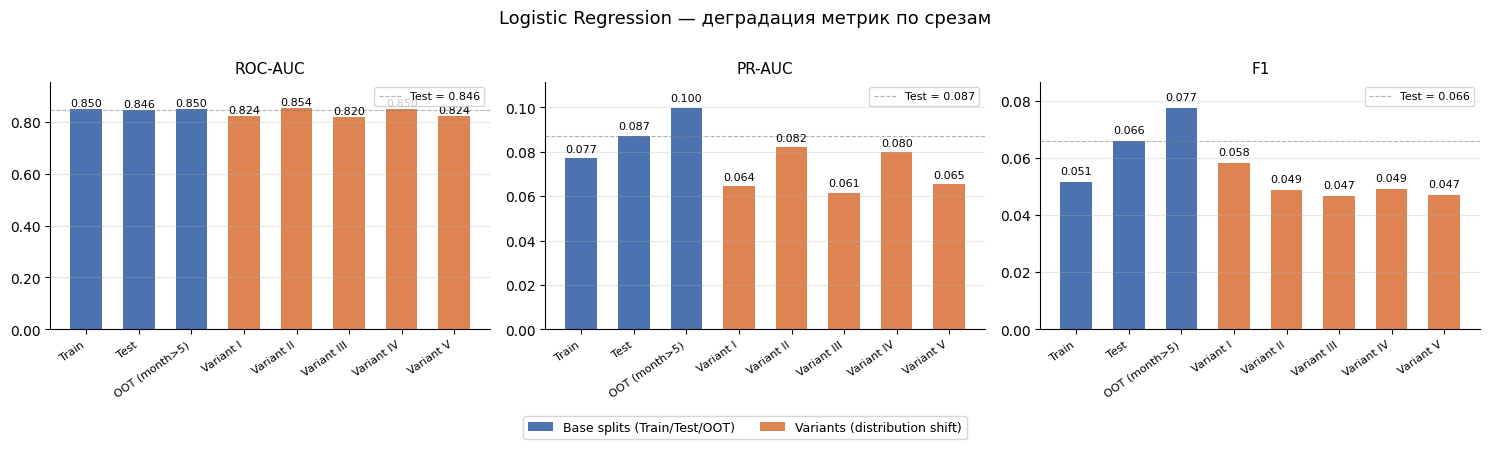

График сохранён: logreg_degradation.png ✓


In [15]:
# ── График деградации метрик ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Logistic Regression — деградация метрик по срезам', fontsize=13, y=1.01)

splits = df_results['Split'].tolist()
colors = ['#4C72B0' if s in ['Train','Test','OOT (month>5)'] else '#DD8452'
          for s in splits]

for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC', 'F1']):
    vals = df_results[metric].values
    bars = ax.bar(range(len(splits)), vals, color=colors, width=0.6)

    # Подписи значений
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(splits)))
    ax.set_xticklabels(splits, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, min(1.0, max(vals) * 1.12))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # Горизонтальная линия = Test
    test_val = df_results.loc[df_results['Split']=='Test', metric].values[0]
    ax.axhline(test_val, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
               label=f'Test = {test_val:.3f}')
    ax.legend(fontsize=8)

# Легенда цветов
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Base splits (Train/Test/OOT)'),
    Patch(facecolor='#DD8452', label='Variants (distribution shift)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.savefig('logreg_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: logreg_degradation.png ✓')

In [16]:
from sklearn.metrics import precision_recall_curve

proba_test = logreg.predict_proba(X_test)[:, 1]
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, proba_test)

# F1 по каждому порогу
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (
    prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_idx = np.argmax(f1_arr)
best_thr = thr_arr[best_idx]

print(f'Оптимальный порог по F1 (Test): {best_thr:.4f}')
print(f'  Precision: {prec_arr[best_idx]:.4f}')
print(f'  Recall   : {rec_arr[best_idx]:.4f}')
print(f'  F1       : {f1_arr[best_idx]:.4f}')
print()
print('Примечание: для финальной таблицы сравнения с ProtoNets')
print('используем порог 0.5 (стандарт), но оптимальный порог')
print('пригодится при анализе precision-recall trade-off.')

Оптимальный порог по F1 (Test): 0.9964
  Precision: 0.1284
  Recall   : 0.2629
  F1       : 0.1725

Примечание: для финальной таблицы сравнения с ProtoNets
используем порог 0.5 (стандарт), но оптимальный порог
пригодится при анализе precision-recall trade-off.


In [17]:
# Сохраняем таблицу метрик
df_results.to_csv('logreg_metrics.csv', index=False)
print('Таблица метрик сохранена: logreg_metrics.csv ✓')

Таблица метрик сохранена: logreg_metrics.csv ✓


## 8. Сохранение модели и скейлера

In [18]:
joblib.dump(logreg,  'logreg_baseline.pkl')
joblib.dump(scaler,  'scaler_baseline.pkl')

print('Модель сохранена  : logreg_baseline.pkl ✓')
print('Скейлер сохранён  : scaler_baseline.pkl ✓')
print()
print('Эти файлы потребуются при:')
print('  • прогоне LightGBM (один скейлер для обоих baseline)')
print('  • финальном сравнении baseline vs ProtoNets')

Модель сохранена  : logreg_baseline.pkl ✓
Скейлер сохранён  : scaler_baseline.pkl ✓

Эти файлы потребуются при:
  • прогоне LightGBM (один скейлер для обоих baseline)
  • финальном сравнении baseline vs ProtoNets
